## Alfven wave advection tests
Here we test the properties of the grid scheme in $z$. It turns out we need quite a few points per wavelength (around 8-10) to adequately resolve a mode.

In [13]:
import os
#os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=8"
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt
import jax_rmhd.snapshot_io as sn
import jax_rmhd.diagnostics as diag
jr.init_cluster()

Running in local mode. Total devices: 1


In [14]:
#parameters
nx = 8
ny = 8
nz = 128
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi
dx = Lx/nx
t = 0.0
nsnap = 100
t_snap=1.0
t_end=3.0
cfl_safety=1.0 #this is pretty aggressive
spatial_dimensions=3
snap_path="data/AW_advection/"

kz = 16

#we will use hyperviscosity
visc=1e-9
res=1e-9
hyper=3

x = jnp.linspace(0, Lx, nx, endpoint=False)
y = jnp.linspace(0, Ly, ny, endpoint=False)
z = jnp.linspace(0, Lz, nz, endpoint=False)
x_grid = x.reshape(1,-1,1)
y_grid = y.reshape(1,1,-1)
z_grid = z.reshape(-1,1,1)

#initialize arrays
#modified Orzag-Tang vortex as described in Loureiro et al. 2016 (Viriato paper)
phi = jnp.cos(x_grid) * jnp.cos(y_grid) * jnp.cos(kz * z_grid)
psi = phi # Only Elsasser z+ is nonzero: should propagate backwards at v_A=1 in code units
#fft
phik=ft.rfft2(phi)
psik=ft.rfft2(psi)

#set up orbax snapshot manager
mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

#prepare necessary objects for simulation
params=jr.Parameters(nx=nx,ny=ny,Lx=Lx,Ly=Ly,nz=nz,Lz=Lz,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions,z_diss=0.25)
shardings=jr.setup_sharding(params)
kgrid = jr.setup_kgrids(params)
state = jr.SimulationState(t=0.0,fields=jr.Fields(phik,psik))

In [15]:
final_state=jr.simulate(state,kgrid,params,t_snap=t_snap,t_end=t_end,mngr=mngr,shardings=shardings)

Saving initial state as snapshot 0
---COMPILING rk_advance---
Saving snapshot 0 at t = 1.0308350894591514
---COMPILING rk_advance---
Saving snapshot 0 at t = 2.061670178918303
Saving snapshot 0 at t = 3.0925052683774505
Ending simulation at t = 3.0925052683774505


Array(0.21711444, dtype=float64)

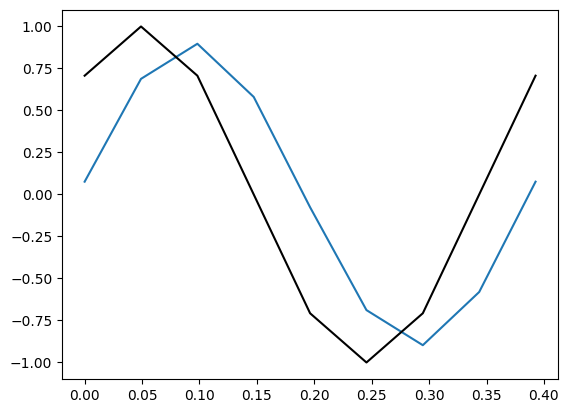

In [16]:
phi=ft.irfft2(final_state.fields.phik)
plt.plot(z[0:nz//kz+1],phi[0:nz//kz+1,nx//2,ny//2])
phi_exact = jnp.cos(kz* (z + final_state.t))
plt.plot(z[0:nz//kz+1],phi_exact[0:nz//kz+1],'k')
err=jnp.sum((phi[:,nx//2,ny//2]-phi_exact)**2)/params.nz
err

In [17]:
kzarr=jnp.arange(32)
errs=[]
squares=[]

params=jr.Parameters(nx=nx,ny=ny,Lx=Lx,Ly=Ly,nz=nz,Lz=Lz,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions,z_diss=0.25)
shardings=jr.setup_sharding(params)
kgrid = jr.setup_kgrids(params)

for kz in kzarr:
    print(kz)
    phi = jnp.cos(x_grid) * jnp.cos(y_grid) * jnp.cos(kz * z_grid)
    psi = phi
    startsq=jnp.sum(phi**2)
    phik=ft.rfft2(phi)
    psik=ft.rfft2(psi)
    start_state = jr.SimulationState(t=0.0,fields=jr.Fields(phik,psik))
    tstop=2*jnp.pi
    final_state=jr.simulate(start_state,kgrid,params,t_snap=tstop,t_end=tstop,mngr=mngr,shardings=shardings,save=False)
    phi_exact = jnp.cos(kz* (z + final_state.t))
    phi = ft.irfft2(final_state.fields.phik)
    errs.append(jnp.sum((phi[:,nx//2,ny//2]-phi_exact)**2)/params.nz)
    squares.append(jnp.sum(phi**2)/startsq)
    plt.plot(z[0:nz//kz+1],phi[0:nz//kz+1,nx//2,ny//2])
    plt.plot(z[0:nz//kz+1],phi_exact[0:nz//kz+1])
    plt.savefig(snap_path+str(kz).zfill(3)+".png")
    plt.close('all')


kz_err_arr=jnp.array(errs)
kz_square_arr=jnp.array(squares)
    

0
---COMPILING rk_advance---
Ending simulation at t = 6.332272692391914
1
Ending simulation at t = 6.332272692391914
2
Ending simulation at t = 6.332272692391914
3
Ending simulation at t = 6.332272692391914
4
Ending simulation at t = 6.332272692391914
5
Ending simulation at t = 6.332272692391914
6
Ending simulation at t = 6.332272692391914
7
Ending simulation at t = 6.332272692391914
8
Ending simulation at t = 6.332272692391914
9
Ending simulation at t = 6.332272692391914
10
Ending simulation at t = 6.332272692391914
11
Ending simulation at t = 6.332272692391914
12
Ending simulation at t = 6.332272692391914
13
Ending simulation at t = 6.332272692391914
14
Ending simulation at t = 6.332272692391914
15
Ending simulation at t = 6.332272692391914
16
Ending simulation at t = 6.332272692391914
17
Ending simulation at t = 6.332272692391914
18
Ending simulation at t = 6.332272692391914
19
Ending simulation at t = 6.332272692391914
20
Ending simulation at t = 6.332272692391914
21
Ending simulat

Text(0, 0.5, 'rms error')

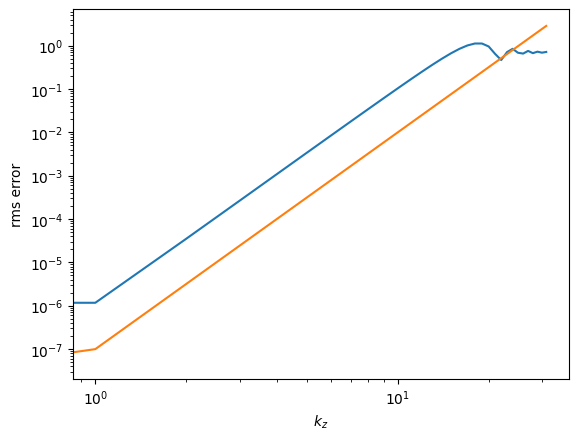

In [18]:
plt.loglog(kzarr,kz_err_arr**0.5)
plt.loglog(kzarr,1e-7*kzarr**5.0)
plt.xlabel(r"$k_z$")
plt.ylabel(r"rms error")

RMS error scales as $k_z^5$ as expected from the 4th order spatial discretization.

Text(0, 0.5, '$\\Delta E/E_0$')

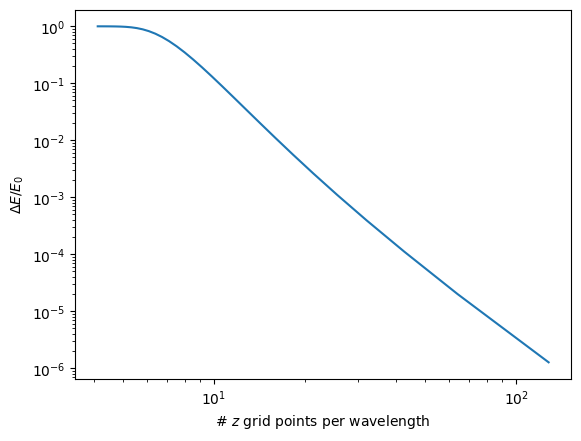

In [19]:
plt.loglog(params.nz/kzarr,1-kz_square_arr)
plt.xlabel(r"# $z$ grid points per wavelength")
plt.ylabel(r"$\Delta E/E_0$")

The error in the norm decreases with the number of grid points per wavelength as expected.

In [ ]:
nzarr=jnp.array([8,16,32,64,128,256,512,1024])
errs=[]
squares=[]

kz=4

for nz in nzarr:
    x = jnp.linspace(0, Lx, nx, endpoint=False)
    y = jnp.linspace(0, Ly, ny, endpoint=False)
    z = jnp.linspace(0, Lz, nz, endpoint=False)
    x_grid = x.reshape(1,-1,1)
    y_grid = y.reshape(1,1,-1)
    z_grid = z.reshape(-1,1,1)
    params=jr.Parameters(nx=nx,ny=ny,Lx=Lx,Ly=Ly,nz=nz,Lz=Lz,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions,z_diss=0.25)
    shardings=jr.setup_sharding(params)
    kgrid = jr.setup_kgrids(params)
    print(nz)
    phi = jnp.cos(x_grid) * jnp.cos(y_grid) * jnp.cos(kz * z_grid)
    psi = phi
    startsq=jnp.sum(phi**2)
    phik=ft.rfft2(phi)
    psik=ft.rfft2(psi)
    start_state = jr.SimulationState(t=0.0,fields=jr.Fields(phik,psik))
    tstop=2*jnp.pi
    final_state=jr.simulate(start_state,kgrid,params,t_snap=tstop,t_end=tstop,mngr=mngr,shardings=shardings,save=False)
    phi_exact = jnp.cos(kz* (z + final_state.t))
    phi = ft.irfft2(final_state.fields.phik)
    errs.append(jnp.sum((phi[:,nx//2,ny//2]-phi_exact)**2)/params.nz)
    squares.append(jnp.sum(phi**2)/startsq)
    plt.plot(z[0:nz//kz+1],phi[0:nz//kz+1,nx//2,ny//2])
    plt.plot(z[0:nz//kz+1],phi_exact[0:nz//kz+1])
    plt.savefig(snap_path+"nz"+str(nz).zfill(3)+"_scan.png")
    plt.close('all')


nz_err_arr=jnp.array(errs)
nz_square_arr=jnp.array(squares)
    


8
---COMPILING rk_advance---
Ending simulation at t = 6.348632093034986
16
---COMPILING rk_advance---
Ending simulation at t = 6.283185307179588
32
---COMPILING rk_advance---
Ending simulation at t = 6.283185307179591
64
---COMPILING rk_advance---
Ending simulation at t = 6.3813600776042625
128
---COMPILING rk_advance---
Ending simulation at t = 6.332272692391914
256
---COMPILING rk_advance---
Ending simulation at t = 6.3077289997857395
512
---COMPILING rk_advance---
Ending simulation at t = 6.28318530717965
1024
---COMPILING rk_advance---


Text(0, 0.5, 'rms error')

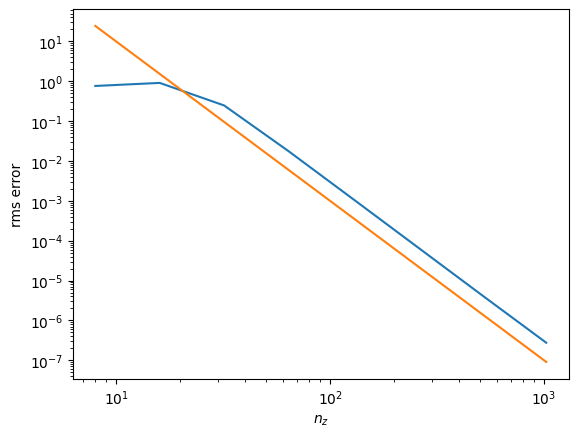

In [ ]:
plt.loglog(nzarr,nz_err_arr**0.5)
plt.loglog(nzarr,1e5*(1.0*nzarr)**-4)
plt.xlabel(r"$n_z$")
plt.ylabel("rms error")

Varying $n_z$: RMS error is proportional to $n_z^{-4}$, as expected.

0
---COMPILING rk_advance---
Ending simulation at t = 6.28809404570066
1
Ending simulation at t = 6.28809404570066
2
Ending simulation at t = 6.28809404570066
3
Ending simulation at t = 6.28809404570066
4
Ending simulation at t = 6.28809404570066
5
Ending simulation at t = 6.28809404570066
6
Ending simulation at t = 6.28809404570066
7
Ending simulation at t = 6.28809404570066
8
Ending simulation at t = 6.28809404570066
9
Ending simulation at t = 6.28809404570066
10
Ending simulation at t = 6.28809404570066
11
Ending simulation at t = 6.28809404570066
12
Ending simulation at t = 6.28809404570066
13
Ending simulation at t = 6.28809404570066
14
Ending simulation at t = 6.28809404570066
15
Ending simulation at t = 6.28809404570066
16
Ending simulation at t = 6.28809404570066
17
Ending simulation at t = 6.28809404570066
18
Ending simulation at t = 6.28809404570066
19
Ending simulation at t = 6.28809404570066
20
Ending simulation at t = 6.28809404570066
21
Ending simulation at t = 6.28809404

Text(0, 0.5, 'rms error')

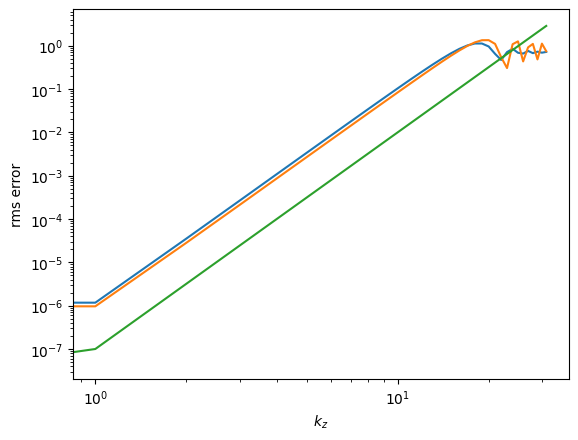

In [ ]:
kzarr=jnp.arange(32)
errs=[]
squares=[]
cfl_safety=0.1
nz=128
x = jnp.linspace(0, Lx, nx, endpoint=False)
y = jnp.linspace(0, Ly, ny, endpoint=False)
z = jnp.linspace(0, Lz, nz, endpoint=False)
x_grid = x.reshape(1,-1,1)
y_grid = y.reshape(1,1,-1)
z_grid = z.reshape(-1,1,1)
params=jr.Parameters(nx=nx,ny=ny,Lx=Lx,Ly=Ly,nz=nz,Lz=Lz,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions,z_diss=0.25)
shardings=jr.setup_sharding(params)
kgrid = jr.setup_kgrids(params)

for kz in kzarr:
    print(kz)
    phi = jnp.cos(x_grid) * jnp.cos(y_grid) * jnp.cos(kz * z_grid)
    psi = phi
    startsq=jnp.sum(phi**2)
    phik=ft.rfft2(phi)
    psik=ft.rfft2(psi)
    start_state = jr.SimulationState(t=0.0,fields=jr.Fields(phik,psik))
    tstop=2*jnp.pi
    final_state=jr.simulate(start_state,kgrid,params,t_snap=tstop,t_end=tstop,mngr=mngr,shardings=shardings,save=False)
    phi_exact = jnp.cos(kz* (z + final_state.t))
    phi = ft.irfft2(final_state.fields.phik)
    errs.append(jnp.sum((phi[:,nx//2,ny//2]-phi_exact)**2)/params.nz)
    squares.append(jnp.sum(phi**2)/startsq)
    plt.plot(z[0:nz//kz+1],phi[0:nz//kz+1,nx//2,ny//2])
    plt.plot(z[0:nz//kz+1],phi_exact[0:nz//kz+1])
    plt.savefig(snap_path+str(kz).zfill(3)+".png")
    plt.close('all')


safe_kz_err_arr=jnp.array(errs)
safe_kz_square_arr=jnp.array(squares)

plt.loglog(kzarr,kz_err_arr**0.5)
plt.loglog(kzarr,safe_kz_err_arr**0.5)
plt.loglog(kzarr,1e-7*kzarr**5.0)
plt.xlabel(r"$k_z$")
plt.ylabel(r"rms error")

Text(0, 0.5, '$\\Delta E/E_0$')

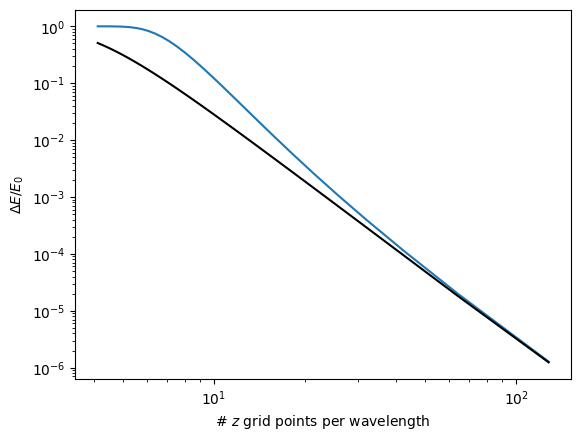

In [ ]:
plt.loglog(params.nz/kzarr,1-kz_square_arr)
plt.loglog(params.nz/kzarr,1-safe_kz_square_arr)
plt.xlabel(r"# $z$ grid points per wavelength")
plt.ylabel(r"$\Delta E/E_0$")

This test shows that decreasing the cfl factor can decrease the numerical dissipation somewhat.